# Projet de Deep Reinforcement Learning (DRL)

Ce notebook implémente un projet complet de Deep Reinforcement Learning en utilisant une **architecture DQN (Deep Q-Network)** sur un environnement classique de contrôle (par exemple `CartPole-v1`).

Nous allons :
- **Définir l’environnement** via Gymnasium ou Gym
- **Construire un réseau de neurones** (architecture DQN simple mais standard)
- **Implémenter la mémoire de rejouement (Replay Buffer)**
- **Mettre en place l’algorithme DQN** (avec réseau cible)
- **Entraîner l’agent** et suivre la récompense moyenne
- **Visualiser et évaluer** le comportement de l’agent


In [ ]:
# Installation / import des bibliothèques nécessaires

# Si gymnasium / gym ou torch ne sont pas installés, décommente les lignes ci-dessous :
# !pip install gymnasium[box2d] gymnasium[classic-control] torch numpy matplotlib
# ou, si tu utilises gym classique :
# !pip install gym torch numpy matplotlib

import random
import math
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# Nous allons essayer d’utiliser gymnasium en priorité, puis gym si non disponible
try:
    import gymnasium as gym
    GYMN_TYPE = "gymnasium"
except ImportError:
    import gym
    GYMN_TYPE = "gym"

print("Version de PyTorch :", torch.__version__)
print("Librairie d'environnement :", GYMN_TYPE)

Version de PyTorch : 2.5.1+cpu
Librairie d'environnement : gymnasium


In [ ]:
# Création de l'environnement CartPole

ENV_NAME = "CartPole-v1"

if GYMN_TYPE == "gymnasium":
    env = gym.make(ENV_NAME)
else:
    env = gym.make(ENV_NAME)

n_states = env.observation_space.shape[0]
n_actions = env.action_space.n

print("Environnement :", ENV_NAME)
print("Dimension de l'état :", n_states)
print("Nombre d'actions :", n_actions)

Environnement : CartPole-v1
Dimension de l'état : 4
Nombre d'actions : 2


In [ ]:
# Définition du réseau DQN

class DQN(nn.Module):
    def __init__(self, n_states, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = DQN(n_states, n_actions).to(device)
target_net = DQN(n_states, n_actions).to(device)

target_net.load_state_dict(policy_net.state_dict())

print(policy_net)

DQN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
# Mémoire de rejouement (Replay Buffer)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


buffer_capacity = 50_000
batch_size = 64
replay_buffer = ReplayBuffer(buffer_capacity)

print("Capacité du buffer :", buffer_capacity)

Capacité du buffer : 50000


In [ ]:
# Hyperparamètres du DQN

gamma = 0.99              # facteur de discount
lr = 1e-3                 # taux d'apprentissage
epsilon_start = 1.0       # epsilon initial (exploration)
epsilon_end = 0.05        # epsilon minimal
epsilon_decay = 500       # contrôlera la décroissance d'epsilon

max_episodes = 400        # tu peux augmenter si tu veux de meilleures perfs
max_steps = 500           # nombre max de steps par épisode

update_target_every = 10  # nombre d'épisodes entre chaque mise à jour du réseau cible

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
loss_fn = nn.MSELoss()

steps_done = 0

def select_action(state):
    global steps_done
    # Stratégie epsilon-greedy
    eps_threshold = epsilon_end + (epsilon_start - epsilon_end) * math.exp(-1. * steps_done / epsilon_decay)
    steps_done += 1

    if random.random() < eps_threshold:
        # exploration
        return random.randrange(n_actions), eps_threshold
    else:
        # exploitation
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = policy_net(state_t)
            action = int(torch.argmax(q_values, dim=1).item())
            return action, eps_threshold

print("Dispositif :", device)

Dispositif : cpu


In [ ]:
# Fonction d'entraînement d'un batch (une itération d'optimisation)

def optimize_model():
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states_t = torch.tensor(states, dtype=torch.float32, device=device)
    actions_t = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
    rewards_t = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states_t = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones_t = torch.tensor(dones.astype(np.float32), dtype=torch.float32, device=device).unsqueeze(1)

    # Q(s, a)
    q_values = policy_net(states_t).gather(1, actions_t)

    # max_a' Q_target(s', a')
    with torch.no_grad():
        max_next_q_values = target_net(next_states_t).max(1)[0].unsqueeze(1)
        target_q_values = rewards_t + (1-dones_t) * gamma * max_next_q_values

    loss = loss_fn(q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    # Optionnel : clip des gradients
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()

    return loss.item()

In [ ]:
# Boucle d'entraînement principale

all_rewards = []
all_losses = []

for episode in range(1, max_episodes + 1):
    if GYMN_TYPE == "gymnasium":
        state, info = env.reset()
    else:
        state = env.reset()

    episode_reward = 0.0
    episode_losses = []

    for t in range(max_steps):
        # Sélection de l'action
        action, eps = select_action(state)

        # Interaction avec l'environnement
        if GYMN_TYPE == "gymnasium":
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        else:
            next_state, reward, done, info = env.step(action)

        # Stockage dans le buffer
        replay_buffer.push(state, action, reward, next_state, done)

        state = next_state
        episode_reward += reward

        # Optimisation sur un batch si possible
        loss = optimize_model()
        if loss is not None:
            episode_losses.append(loss)

        if done:
            break

    all_rewards.append(episode_reward)
    if episode_losses:
        all_losses.append(np.mean(episode_losses))
    else:
        all_losses.append(None)

    # Mise à jour du réseau cible tous les N épisodes
    if episode % update_target_every == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Affichage progressif
    if episode % 10 == 0:
        mean_reward_last_10 = np.mean(all_rewards[-10:])
        print(f"Episode {episode}/{max_episodes} | Récompense moy (10 derniers): {mean_reward_last_10:.2f} | Epsilon: {eps:.3f}")

print("Entraînement terminé.")

Episode 10/400 | Récompense moy (10 derniers): 41.60 | Epsilon: 0.464
Episode 20/400 | Récompense moy (10 derniers): 19.80 | Epsilon: 0.329
Episode 30/400 | Récompense moy (10 derniers): 27.00 | Epsilon: 0.212
Episode 40/400 | Récompense moy (10 derniers): 162.30 | Epsilon: 0.056
Episode 50/400 | Récompense moy (10 derniers): 162.80 | Epsilon: 0.050
Episode 60/400 | Récompense moy (10 derniers): 158.30 | Epsilon: 0.050
Episode 70/400 | Récompense moy (10 derniers): 177.30 | Epsilon: 0.050
Episode 80/400 | Récompense moy (10 derniers): 186.00 | Epsilon: 0.050
Episode 90/400 | Récompense moy (10 derniers): 156.40 | Epsilon: 0.050
Episode 100/400 | Récompense moy (10 derniers): 188.80 | Epsilon: 0.050
Episode 110/400 | Récompense moy (10 derniers): 241.70 | Epsilon: 0.050
Episode 120/400 | Récompense moy (10 derniers): 209.50 | Epsilon: 0.050
Episode 130/400 | Récompense moy (10 derniers): 173.40 | Epsilon: 0.050
Episode 140/400 | Récompense moy (10 derniers): 171.40 | Epsilon: 0.050
Epis

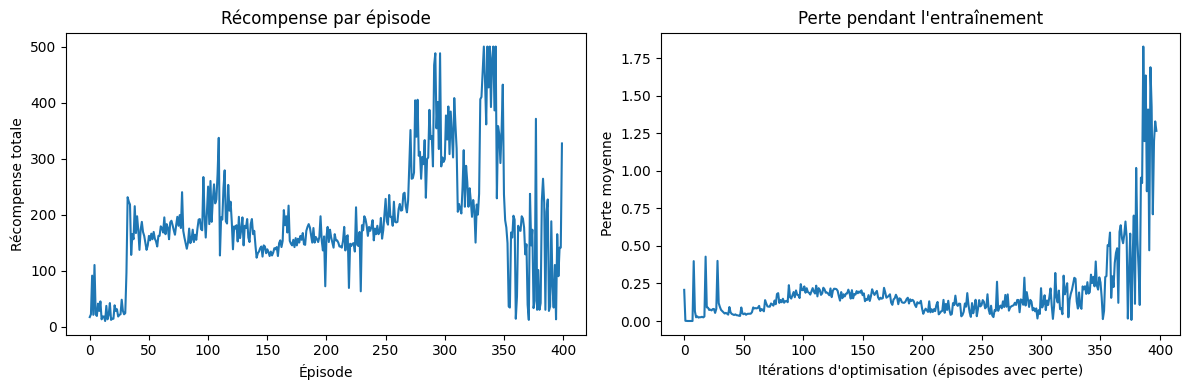

In [ ]:
# Visualisation des récompenses et des pertes

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(all_rewards)
plt.xlabel("Épisode")
plt.ylabel("Récompense totale")
plt.title("Récompense par épisode")

plt.subplot(1, 2, 2)
plt.plot([l for l in all_losses if l is not None])
plt.xlabel("Itérations d'optimisation (épisodes avec perte)")
plt.ylabel("Perte moyenne")
plt.title("Perte pendant l'entraînement")

plt.tight_layout()
plt.show()

In [ ]:
# Évaluation / visualisation du comportement de l'agent entraîné

def run_episode(env, render=False):
    if GYMN_TYPE == "gymnasium":
        state, info = env.reset()
    else:
        state = env.reset()

    total_reward = 0
    for t in range(max_steps):
        if render:
            env.render()

        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = policy_net(state_t)
            action = int(torch.argmax(q_values, dim=1).item())

        if GYMN_TYPE == "gymnasium":
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        else:
            next_state, reward, done, info = env.step(action)

        state = next_state
        total_reward += reward
        if done:
            break

    return total_reward

# Exemple : évaluer sur quelques épisodes sans rendu graphique
n_eval_episodes = 10
rewards_eval = [run_episode(env, render=False) for _ in range(n_eval_episodes)]

print(f"Récompense moyenne sur {n_eval_episodes} épisodes d'évaluation : {np.mean(rewards_eval):.2f}")

# === Démo Pygame / rendu humain, relançable facilement ===
# Cette fonction crée un nouvel environnement avec render_mode="human",
# lance plusieurs épisodes avec rendu, puis ferme proprement la fenêtre.

def demo_humaine_cartpole(n_episodes=3):
    env_render = gym.make(ENV_NAME, render_mode="human")
    try:
        for i in range(n_episodes):
            r = run_episode(env_render, render=True)
            print(f"Épisode rendu {i+1}/{n_episodes} | Récompense : {r:.2f}")
    finally:
        env_render.close()

# Pour lancer la démo Pygame, exécute simplement :
demo_humaine_cartpole(n_episodes=5)

Récompense moyenne sur 10 épisodes d'évaluation : 231.80
Épisode rendu 1/5 | Récompense : 236.00
Épisode rendu 2/5 | Récompense : 300.00
Épisode rendu 3/5 | Récompense : 196.00
Épisode rendu 4/5 | Récompense : 207.00
Épisode rendu 5/5 | Récompense : 244.00
